In [1]:
# Problema: Decidir a qué contribuyentes auditar con una capacidad limitada de días de inspección, para maximizar el recaudo esperado sin poder revisar a todos.
# Caso sintético: decidimos dónde intervenir; las probabilidades son insumos.

from pathlib import Path
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from IPython.display import display
from IPython import get_ipython
import pulp

data_dir = Path("../data")
submission_dir = Path("../submission")
get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
display(["taxpayers.csv", "audit_capacity.csv"])

['taxpayers.csv', 'audit_capacity.csv']

In [2]:
# El monto es recuperable condicionado al incumplimiento; las inspecciones son indivisibles.

taxpayers = pd.read_csv(data_dir / "taxpayers.csv").sort_values("taxpayer_id")
audit_capacity = pd.read_csv(data_dir / "audit_capacity.csv")
B = int(audit_capacity.loc[0, "inspection_days_available"])
display(taxpayers, audit_capacity)

,taxpayer_id,risk_probability,recoverable_amount,inspection_days
0,T01,0.95,200,3
1,T02,0.90,300,4
2,T03,0.85,400,5
3,T04,0.80,2000,10
4,T05,0.75,1600,6
5,T06,0.50,1900,5
6,T07,0.60,1500,5
7,T08,0.40,1900,4
8,T09,0.55,600,3
9,T10,0.50,500,3


,capacity_id,inspection_days_available
0,BASE,14


In [3]:
# No hay características protegidas; el objetivo limitado es recuperación esperada.

assert len(taxpayers) == 12 and taxpayers.taxpayer_id.is_unique
assert not taxpayers.isna().any().any()
assert taxpayers.risk_probability.between(0, 1).all()
assert taxpayers.recoverable_amount.ge(0).all()
assert taxpayers.inspection_days.gt(0).all()
assert taxpayers.inspection_days.mod(1).eq(0).all()
assert len(audit_capacity) == 1 and B == 14
print(f"{len(taxpayers)} contribuyentes; {B} jornadas disponibles.")

12 contribuyentes; 14 jornadas disponibles.


In [4]:
# El riesgo no basta: el impacto depende también del monto recuperable.

taxpayers["expected_recovery"] = (
    taxpayers.risk_probability * taxpayers.recoverable_amount
)
display(
    taxpayers[
        ["taxpayer_id", "risk_probability", "recoverable_amount", "expected_recovery"]
    ]
)

,taxpayer_id,risk_probability,recoverable_amount,expected_recovery
0,T01,0.95,200,190.0
1,T02,0.90,300,270.0
2,T03,0.85,400,340.0
3,T04,0.80,2000,1600.0
4,T05,0.75,1600,1200.0
5,T06,0.50,1900,950.0
6,T07,0.60,1500,900.0
7,T08,0.40,1900,760.0
8,T09,0.55,600,330.0
9,T10,0.50,500,250.0


In [5]:
# La eficiencia relaciona el valor esperado con el recurso consumido.

taxpayers["expected_recovery_per_day"] = (
    taxpayers.expected_recovery / taxpayers.inspection_days
)
display(
    taxpayers[
        [
            "taxpayer_id",
            "inspection_days",
            "expected_recovery",
            "expected_recovery_per_day",
        ]
    ]
)

,taxpayer_id,inspection_days,expected_recovery,expected_recovery_per_day
0,T01,3,190.0,63.333333
1,T02,4,270.0,67.500000
2,T03,5,340.0,68.000000
3,T04,10,1600.0,160.000000
4,T05,6,1200.0,200.000000
5,T06,5,950.0,190.000000
6,T07,5,900.0,180.000000
7,T08,4,760.0,190.000000
8,T09,3,330.0,110.000000
9,T10,3,250.0,83.333333


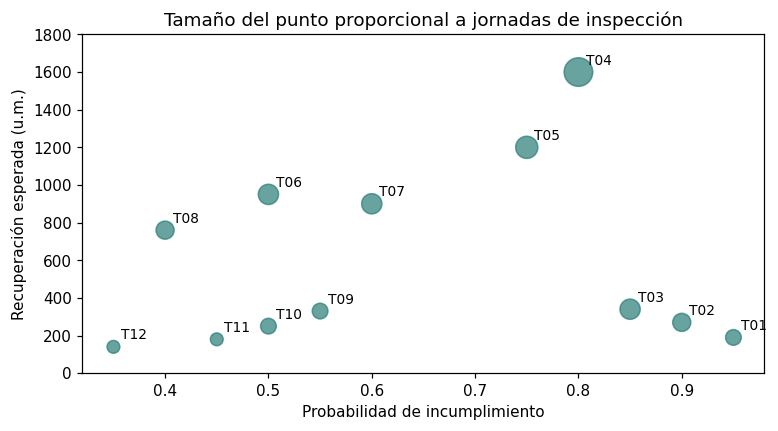

In [6]:
# Riesgo, impacto y esfuerzo responden preguntas distintas.

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(
    taxpayers.risk_probability,
    taxpayers.expected_recovery,
    s=taxpayers.inspection_days * 35,
    color="#287d78",
    alpha=0.7,
)
for row in taxpayers.itertuples():
    ax.annotate(
        row.taxpayer_id,
        (row.risk_probability, row.expected_recovery),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )
ax.set(
    xlabel="Probabilidad de incumplimiento",
    ylabel="Recuperación esperada (u.m.)",
    title="Tamaño del punto proporcional a jornadas de inspección",
    ylim=(0, 1800),
)
plt.show()

In [7]:
# Política ingenua: atender primero los incumplimientos más probables.

risk_order = taxpayers.sort_values(
    ["risk_probability", "taxpayer_id"], ascending=[False, True]
)
risk_ranks = pd.Series(range(1, 13), index=risk_order.taxpayer_id)
display(risk_order[["taxpayer_id", "risk_probability", "inspection_days"]])

,taxpayer_id,risk_probability,inspection_days
0,T01,0.95,3
1,T02,0.90,4
2,T03,0.85,5
3,T04,0.80,10
4,T05,0.75,6
6,T07,0.60,5
8,T09,0.55,3
5,T06,0.50,5
9,T10,0.50,3
10,T11,0.45,2


In [8]:
# Seleccionar si cabe; en caso contrario, omitir y continuar sin fraccionar.

remaining = B
risk_ids, risk_trace = [], []
for row in risk_order.itertuples():
    selected = row.inspection_days <= remaining
    if selected:
        risk_ids.append(row.taxpayer_id)
        remaining -= row.inspection_days
    risk_trace.append([row.taxpayer_id, row.inspection_days, selected, remaining])
risk_trace = pd.DataFrame(
    risk_trace, columns=["taxpayer_id", "inspection_days", "selected", "remaining_days"]
)
display(risk_trace)

,taxpayer_id,inspection_days,selected,remaining_days
0,T01,3,True,11
1,T02,4,True,7
2,T03,5,True,2
3,T04,10,False,2
4,T05,6,False,2
5,T07,5,False,2
6,T09,3,False,2
7,T06,5,False,2
8,T10,3,False,2
9,T11,2,True,0


In [9]:
# T01 tiene riesgo 0.95, pero su monto pequeño limita el valor de inspeccionarlo.

risk_portfolio = taxpayers[taxpayers.taxpayer_id.isin(risk_ids)]
risk_total = risk_portfolio.expected_recovery.sum()
display(
    risk_portfolio[
        ["taxpayer_id", "risk_probability", "expected_recovery", "inspection_days"]
    ]
)
print(
    f"Recuperación: {risk_total:.0f}; jornadas: {risk_portfolio.inspection_days.sum()}"
)

,taxpayer_id,risk_probability,expected_recovery,inspection_days
0,T01,0.95,190.0,3
1,T02,0.90,270.0,4
2,T03,0.85,340.0,5
10,T11,0.45,180.0,2


Recuperación: 980; jornadas: 14


In [10]:
# Mismo presupuesto y regla de selección, ahora ordenando por impacto esperado.

value_order = taxpayers.sort_values(
    ["expected_recovery", "taxpayer_id"], ascending=[False, True]
)
value_ranks = pd.Series(range(1, 13), index=value_order.taxpayer_id)
remaining = B
value_ids = []
for row in value_order.itertuples():
    if row.inspection_days <= remaining:
        value_ids.append(row.taxpayer_id)
        remaining -= row.inspection_days
value_portfolio = taxpayers[taxpayers.taxpayer_id.isin(value_ids)]
value_total = value_portfolio.expected_recovery.sum()
display(value_portfolio[["taxpayer_id", "expected_recovery", "inspection_days"]])
print(f"Recuperación: {value_total:.0f}; jornadas: {B - remaining}")

,taxpayer_id,expected_recovery,inspection_days
3,T04,1600.0,10
7,T08,760.0,4


Recuperación: 2360; jornadas: 14


In [11]:
# Un riesgo menor puede corresponder a una intervención de mayor valor.

display(
    taxpayers.loc[
        taxpayers.taxpayer_id.isin(["T01", "T08"]),
        ["taxpayer_id", "risk_probability", "recoverable_amount", "expected_recovery"],
    ]
)
print(
    f"Mejora de la cartera por recuperación frente a riesgo: {value_total - risk_total:.0f}"
)

,taxpayer_id,risk_probability,recoverable_amount,expected_recovery
0,T01,0.95,200,190.0
7,T08,0.40,1900,760.0


Mejora de la cartera por recuperación frente a riesgo: 1380


In [12]:
# Un buen rendimiento por jornada puede mejorar la cartera, sin garantizar el óptimo.

efficiency_order = taxpayers.sort_values(
    ["expected_recovery_per_day", "taxpayer_id"], ascending=[False, True]
)
efficiency_ranks = pd.Series(range(1, 13), index=efficiency_order.taxpayer_id)
remaining = B
efficiency_ids, efficiency_trace = [], []
for row in efficiency_order.itertuples():
    before = remaining
    selected = row.inspection_days <= remaining
    if selected:
        efficiency_ids.append(row.taxpayer_id)
        remaining -= row.inspection_days
    efficiency_trace.append(
        [
            row.taxpayer_id,
            row.inspection_days,
            row.expected_recovery_per_day,
            before,
            selected,
            remaining,
        ]
    )
efficiency_portfolio = taxpayers[taxpayers.taxpayer_id.isin(efficiency_ids)]
efficiency_total = efficiency_portfolio.expected_recovery.sum()
display(efficiency_portfolio[["taxpayer_id", "expected_recovery", "inspection_days"]])
print(f"Recuperación: {efficiency_total:.0f}; jornadas: {B - remaining}")

,taxpayer_id,expected_recovery,inspection_days
4,T05,1200.0,6
5,T06,950.0,5
8,T09,330.0,3


Recuperación: 2480; jornadas: 14


In [13]:
# Tras T05 y T06 quedan tres días: T08 y T07 no caben; termina entrando T09.

efficiency_trace = pd.DataFrame(
    efficiency_trace,
    columns=[
        "taxpayer_id",
        "inspection_days",
        "efficiency",
        "days_before",
        "selected",
        "days_after",
    ],
)
display(efficiency_trace.head(6))

,taxpayer_id,inspection_days,efficiency,days_before,selected,days_after
0,T05,6,200.0,14,True,8
1,T06,5,190.0,8,True,3
2,T08,4,190.0,3,False,3
3,T07,5,180.0,3,False,3
4,T04,10,160.0,3,False,3
5,T09,3,110.0,3,True,0


In [14]:
# MODEL
# ---------------------------------------------------------------------
# Sets:
#   i in TAXPAYERS
#
# Parameters:
#   p[i]      risk probability
#   a[i]      recoverable amount conditional on non-compliance
#   e[i]      inspection days
#   B         available inspection days
#
# Derived:
#   v[i] = p[i] * a[i]
#
# Decision variable:
#   x[i] binary
#
# Objective:
#   maximize expected_recovery:
#       sum{i in TAXPAYERS} v[i] * x[i]
#
# Constraint:
#   subject to audit_capacity:
#       sum{i in TAXPAYERS} e[i] * x[i] <= B

ids = taxpayers.taxpayer_id.tolist()
e = taxpayers.inspection_days.to_numpy()
v = taxpayers.expected_recovery.to_numpy()
display(pd.DataFrame({"taxpayer_id": ids, "v": v, "e": e}))

,taxpayer_id,v,e
0,T01,190.0,3
1,T02,270.0,4
2,T03,340.0,5
3,T04,1600.0,10
4,T05,1200.0,6
5,T06,950.0,5
6,T07,900.0,5
7,T08,760.0,4
8,T09,330.0,3
9,T10,250.0,3


In [15]:
# Evaluamos combinaciones completas: los rankings no capturan todas sus interacciones.

feasible_subsets = []
for selection in product([0, 1], repeat=len(ids)):
    days = sum(e[i] * selection[i] for i in range(len(ids)))
    if days > B:
        continue
    recovery = sum(v[i] * selection[i] for i in range(len(ids)))
    selected_ids = tuple(ids[i] for i in range(len(ids)) if selection[i])
    feasible_subsets.append((recovery, selected_ids, days))
feasible_subsets.sort(key=lambda item: (-item[0], item[1]))
print(f"{2 ** len(ids)} subconjuntos evaluados; {len(feasible_subsets)} factibles.")

4096 subconjuntos evaluados; 359 factibles.


In [16]:
# La unicidad distingue una recomendación concreta de alternativas empatadas.

optimal_total, optimal_ids, optimal_days = feasible_subsets[0]
optimal_count = sum(np.isclose(row[0], optimal_total) for row in feasible_subsets)
second_best = feasible_subsets[1]
exhaustive_objective, exhaustive_selection = optimal_total, optimal_ids
display(
    pd.DataFrame(
        feasible_subsets[:2],
        columns=["expected_recovery", "selected_ids", "inspection_days"],
    )
)
print(f"Número de óptimos: {optimal_count}")

,expected_recovery,selected_ids,inspection_days
0,2610.0,"(T06, T07, T08)",14
1,2480.0,"(T05, T06, T09)",14


Número de óptimos: 1


In [17]:
# Construimos el mismo modelo binario con PuLP; HiGHS lo resolverá a continuación.

v_by_id = dict(zip(ids, v))
e_by_id = dict(zip(ids, e))
model = pulp.LpProblem("tax_inspections", pulp.LpMaximize)
x = {i: pulp.LpVariable(f"x_{i}", cat="Binary") for i in ids}
model += pulp.lpSum(v_by_id[i] * x[i] for i in ids)
model += pulp.lpSum(e_by_id[i] * x[i] for i in ids) <= B
display(pd.Series({"variables": len(x), "capacity_constraints": 1}))

variables               12
capacity_constraints     1
dtype: int64

In [18]:
# Resolvemos el mismo modelo con un solver profesional en lugar de enumeración.

solver = pulp.HiGHS(msg=False)
status = model.solve(solver)
assert pulp.LpStatus[status] == "Optimal"
solver_objective = round(pulp.value(model.objective), 2)
solver_selection = tuple(i for i in ids if x[i].value() > 0.5)
solver_days = sum(e_by_id[i] for i in solver_selection)
display(
    pd.DataFrame({"taxpayer_id": solver_selection, "x": [1] * len(solver_selection)})
)
print(
    f"Estado: {pulp.LpStatus[status]}; objetivo HiGHS: {solver_objective:.2f}; jornadas: {solver_days}"
)

,taxpayer_id,x
0,T06,1
1,T07,1
2,T08,1


Estado: Optimal; objetivo HiGHS: 2610.00; jornadas: 14


In [19]:
# La búsqueda exhaustiva expone el espacio de decisiones; el solver la resuelve de forma escalable.

assert np.isclose(solver_objective, exhaustive_objective)
assert solver_selection == exhaustive_selection
assert all(x[i].value() in (0, 1) for i in ids)
assert solver_days <= B
assert set(solver_selection).issubset(set(ids))
assert np.isclose(sum(v_by_id[i] for i in solver_selection), solver_objective)
print(f"Exhaustive search objective : {exhaustive_objective:.2f}")
print(f"HiGHS objective             : {solver_objective:.2f}")
print(f"Selections agree            : {solver_selection == exhaustive_selection}")
print(f"Capacity used               : {solver_days} / {B} days")
print(f"Solver status               : {pulp.LpStatus[status]}")

Exhaustive search objective : 2610.00
HiGHS objective             : 2610.00
Selections agree            : True
Capacity used               : 14 / 14 days
Solver status               : Optimal


In [20]:
# Con T06 fijo, ambas alternativas utilizan exactamente las otras nueve jornadas.

exchange_rows = []
for label, group in [("T05 + T09", ["T05", "T09"]), ("T07 + T08", ["T07", "T08"])]:
    part = taxpayers[taxpayers.taxpayer_id.isin(group)]
    exchange_rows.append(
        [label, part.inspection_days.sum(), part.expected_recovery.sum()]
    )
exchange = pd.DataFrame(
    exchange_rows, columns=["combination", "inspection_days", "expected_recovery"]
)
display(exchange)

,combination,inspection_days,expected_recovery
0,T05 + T09,9,1530.0
1,T07 + T08,9,1660.0


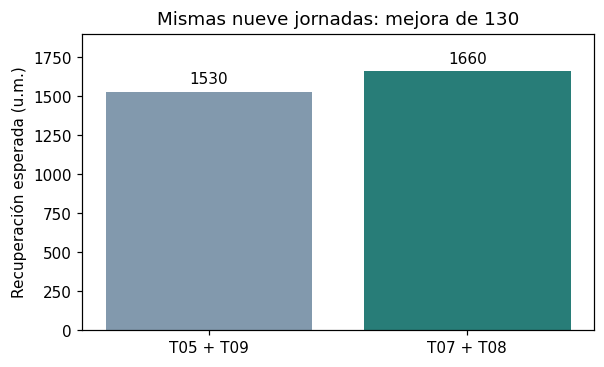

2610 − 2480 = 130


In [21]:
# El mejor cociente individual no garantiza la mejor cartera de acciones indivisibles.

exchange_gain = exchange.expected_recovery.iloc[1] - exchange.expected_recovery.iloc[0]
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(
    exchange.combination, exchange.expected_recovery, color=["#8299ad", "#287d78"]
)
ax.bar_label(bars, fmt="%.0f", padding=3)
ax.set(
    ylabel="Recuperación esperada (u.m.)",
    ylim=(0, 1900),
    title=f"Mismas nueve jornadas: mejora de {exchange_gain:.0f}",
)
plt.show()
print(f"{optimal_total:.0f} − {efficiency_total:.0f} = {exchange_gain:.0f}")

In [22]:
# Excluir T04 no implica falta de valor: sus diez días desplazan una combinación superior.

best_with_t04 = next(row for row in feasible_subsets if "T04" in row[1])
display(
    taxpayers.loc[
        taxpayers.taxpayer_id.isin(best_with_t04[1]),
        ["taxpayer_id", "expected_recovery", "inspection_days"],
    ]
)
print(f"Mejor cartera con T04: {best_with_t04[0]:.0f} < óptimo {optimal_total:.0f}")

,taxpayer_id,expected_recovery,inspection_days
3,T04,1600.0,10
7,T08,760.0,4


Mejor cartera con T04: 2360 < óptimo 2610


In [23]:
# Comparación justa: mismos datos, inspecciones indivisibles y presupuesto.

policy_ids = {
    "risk": risk_ids,
    "expected_recovery": value_ids,
    "efficiency": efficiency_ids,
    "optimized": list(optimal_ids),
}
comparison_rows = []
for policy, selected_ids in policy_ids.items():
    part = taxpayers[taxpayers.taxpayer_id.isin(selected_ids)]
    used = part.inspection_days.sum()
    total = part.expected_recovery.sum()
    comparison_rows.append(
        [policy, B, used, B - used, len(part), total, optimal_total - total, used <= B]
    )
portfolio_comparison = pd.DataFrame(
    comparison_rows,
    columns=[
        "policy",
        "inspection_days_available",
        "inspection_days_used",
        "remaining_days",
        "inspection_count",
        "total_expected_recovery",
        "gap_to_optimum",
        "feasible",
    ],
)
display(
    portfolio_comparison.assign(
        selected_taxpayer_ids=[
            ";".join(policy_ids[p]) for p in portfolio_comparison.policy
        ]
    )
)

,policy,inspection_days_available,inspection_days_used,remaining_days,inspection_count,total_expected_recovery,gap_to_optimum,feasible,selected_taxpayer_ids
0,risk,14,14,0,4,980.0,1630.0,True,T01;T02;T03;T11
1,expected_recovery,14,14,0,2,2360.0,250.0,True,T04;T08
2,efficiency,14,14,0,3,2480.0,130.0,True,T05;T06;T09
3,optimized,14,14,0,3,2610.0,0.0,True,T06;T07;T08


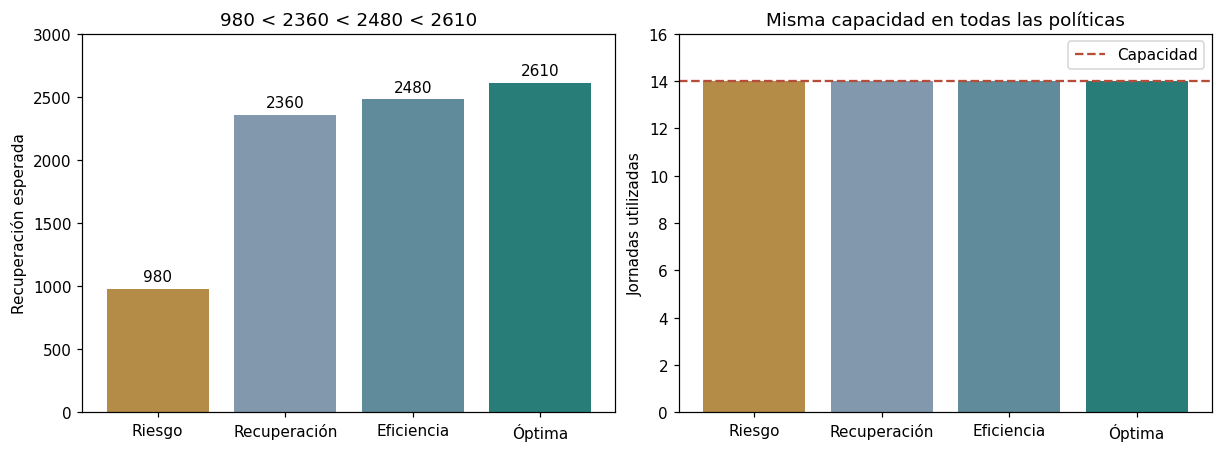

In [24]:
# Agotar el presupuesto no implica aprovecharlo bien.

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
policy_labels = ["Riesgo", "Recuperación", "Eficiencia", "Óptima"]
policy_colors = ["#b48b47", "#8299ad", "#608b9a", "#287d78"]
bars = axes[0].bar(
    policy_labels, portfolio_comparison.total_expected_recovery, color=policy_colors
)
axes[0].bar_label(bars, fmt="%.0f", padding=3)
axes[0].set(
    ylabel="Recuperación esperada", ylim=(0, 3000), title="980 < 2360 < 2480 < 2610"
)
axes[1].bar(
    policy_labels, portfolio_comparison.inspection_days_used, color=policy_colors
)
axes[1].axhline(B, color="#b64d39", linestyle="--", label="Capacidad")
axes[1].set(
    ylabel="Jornadas utilizadas",
    ylim=(0, 16),
    title="Misma capacidad en todas las políticas",
)
axes[1].legend()
plt.show()

In [25]:
# Resolvemos el mismo modelo con B = 12, 14 y 16; los datos predictivos no cambian.

sensitivity_rows = []
for budget in [B - 2, B, B + 2]:
    candidates = []
    for selection in product([0, 1], repeat=len(ids)):
        days = sum(e[i] * selection[i] for i in range(len(ids)))
        if days > budget:
            continue
        total = sum(v[i] * selection[i] for i in range(len(ids)))
        selected_ids = tuple(ids[i] for i in range(len(ids)) if selection[i])
        candidates.append((total, selected_ids, days))
    candidates.sort(key=lambda item: (-item[0], item[1]))
    total, selected_ids, used = candidates[0]
    unique = sum(np.isclose(row[0], total) for row in candidates) == 1
    sensitivity_rows.append(
        [
            budget,
            ";".join(selected_ids),
            used,
            budget - used,
            len(selected_ids),
            total,
            unique,
        ]
    )
capacity_sensitivity = pd.DataFrame(
    sensitivity_rows,
    columns=[
        "inspection_days_available",
        "selected_taxpayer_ids",
        "inspection_days_used",
        "remaining_days",
        "inspection_count",
        "total_expected_recovery",
        "unique_optimum",
    ],
)
display(capacity_sensitivity)

,inspection_days_available,selected_taxpayer_ids,inspection_days_used,remaining_days,inspection_count,total_expected_recovery,unique_optimum
0,12,T05;T06,11,1,2,2150.0,True
1,14,T06;T07;T08,14,0,3,2610.0,True
2,16,T05;T06;T07,16,0,3,3050.0,True


In [26]:
# Los conjuntos no son anidados: más recursos pueden cambiar la composición.

sensitivity_sets = [
    set(value.split(";")) for value in capacity_sensitivity.selected_taxpayer_ids
]
changes = []
for i in range(2):
    changes.append(
        [
            capacity_sensitivity.inspection_days_available.iloc[i],
            capacity_sensitivity.inspection_days_available.iloc[i + 1],
            sorted(sensitivity_sets[i + 1] - sensitivity_sets[i]),
            sorted(sensitivity_sets[i] - sensitivity_sets[i + 1]),
        ]
    )
display(
    pd.DataFrame(
        changes, columns=["capacity_before", "capacity_after", "enter", "leave"]
    )
)

,capacity_before,capacity_after,enter,leave
0,12,14,"[T07, T08]",[T05]
1,14,16,[T05],[T08]


In [27]:
# Tres rankings diagnósticos y cuatro selecciones; no existe aquí un ranking óptimo.

inspection_decisions = taxpayers.copy()
for name, ranks in [
    ("risk", risk_ranks),
    ("expected_recovery", value_ranks),
    ("efficiency", efficiency_ranks),
]:
    inspection_decisions[f"{name}_rank"] = inspection_decisions.taxpayer_id.map(ranks)
for policy, selected_ids in policy_ids.items():
    inspection_decisions[f"selected_{policy}"] = inspection_decisions.taxpayer_id.isin(
        selected_ids
    ).astype(int)
display(
    inspection_decisions[
        [
            "taxpayer_id",
            "risk_rank",
            "expected_recovery_rank",
            "efficiency_rank",
            "selected_optimized",
        ]
    ]
)

,taxpayer_id,risk_rank,expected_recovery_rank,efficiency_rank,selected_optimized
0,T01,1,10,12,0
1,T02,2,8,11,0
2,T03,3,6,10,0
3,T04,4,1,5,0
4,T05,5,2,1,0
5,T06,8,3,2,1
6,T07,6,4,4,1
7,T08,11,5,3,1
8,T09,7,7,6,0
9,T10,9,9,8,0


In [28]:
# La sensibilidad no sustituye la recomendación base de catorce jornadas.

assert (
    len(inspection_decisions) == 12
    and len(portfolio_comparison) == 4
    and len(capacity_sensitivity) == 3
)
display(
    portfolio_comparison[
        ["policy", "inspection_days_used", "total_expected_recovery", "gap_to_optimum"]
    ],
    capacity_sensitivity[
        [
            "inspection_days_available",
            "selected_taxpayer_ids",
            "total_expected_recovery",
        ]
    ],
)

,policy,inspection_days_used,total_expected_recovery,gap_to_optimum
0,risk,14,980.0,1630.0
1,expected_recovery,14,2360.0,250.0
2,efficiency,14,2480.0,130.0
3,optimized,14,2610.0,0.0


,inspection_days_available,selected_taxpayer_ids,total_expected_recovery
0,12,T05;T06,2150.0
1,14,T06;T07;T08,2610.0
2,16,T05;T06;T07,3050.0


In [29]:
# Construimos la figura sin registrarla en pyplot: no se muestra incompleta.

planner = Figure(figsize=(18, 13), layout="constrained")
grid = planner.add_gridspec(3, 2, height_ratios=[1.65, 1, 0.85])
data_ax = planner.add_subplot(grid[0, :])
recovery_ax = planner.add_subplot(grid[1, 0])
exchange_ax = planner.add_subplot(grid[1, 1])
sensitivity_ax = planner.add_subplot(grid[2, 0])
explanation_ax = planner.add_subplot(grid[2, 1])
data_ax.axis("off")
headers = [
    "ID",
    "Riesgo",
    "Recup. esp.",
    "Días",
    "Valor/día",
    "Rango R",
    "Rango V",
    "Rango E",
    "Sel. R",
    "Sel. V",
    "Sel. E",
    "Óptima",
]
visual_rows = [
    [
        r.taxpayer_id,
        f"{r.risk_probability:.2f}",
        f"{r.expected_recovery:.0f}",
        r.inspection_days,
        f"{r.expected_recovery_per_day:.2f}",
        r.risk_rank,
        r.expected_recovery_rank,
        r.efficiency_rank,
        r.selected_risk,
        r.selected_expected_recovery,
        r.selected_efficiency,
        r.selected_optimized,
    ]
    for r in inspection_decisions.itertuples()
]
visual_table = data_ax.table(
    cellText=visual_rows, colLabels=headers, cellLoc="center", bbox=[0, 0, 1, 0.92]
)
visual_table.auto_set_font_size(False)
visual_table.set_fontsize(10)
for i, selected in enumerate(inspection_decisions.selected_optimized, 1):
    if selected:
        for j in range(len(headers)):
            visual_table[(i, j)].set_facecolor("#def0e9")
data_ax.set_title(
    "R = riesgo; V = recuperación esperada; E = eficiencia. Selección: 1 sí, 0 no.",
    fontsize=12,
);

In [30]:
# La comparación explica tanto el conjunto recomendado como sus exclusiones.

bars = recovery_ax.bar(
    policy_labels, portfolio_comparison.total_expected_recovery, color=policy_colors
)
recovery_ax.bar_label(bars, fmt="%.0f", padding=4)
recovery_ax.set(
    title="Recuperación por cartera: todas usan 14/14 jornadas",
    ylabel="Recuperación esperada (u.m.)",
    ylim=(0, 3100),
)
bars = exchange_ax.bar(
    exchange.combination, exchange.expected_recovery, color=["#608b9a", "#287d78"]
)
exchange_ax.bar_label(bars, fmt="%.0f", padding=4)
exchange_ax.set(
    title=f"T06 fijo; otras nueve jornadas: mejora {exchange_gain:.0f}",
    ylabel="Recuperación esperada (u.m.)",
    ylim=(0, 2000),
)
explanation_ax.axis("off")
explanation_ax.text(
    0,
    0.95,
    "Recomendación: T06, T07, T08\n14 jornadas; recuperación esperada 2610\n\nT04: 1600 de valor, pero necesita 10 días.\nMejor complemento: T08, 760 en 4 días.\n1600 + 760 = 2360 < 2610.\n\nUn cociente individual no determina\nla mejor combinación indivisible.",
    transform=explanation_ax.transAxes,
    va="top",
    fontsize=12,
    linespacing=1.4,
);

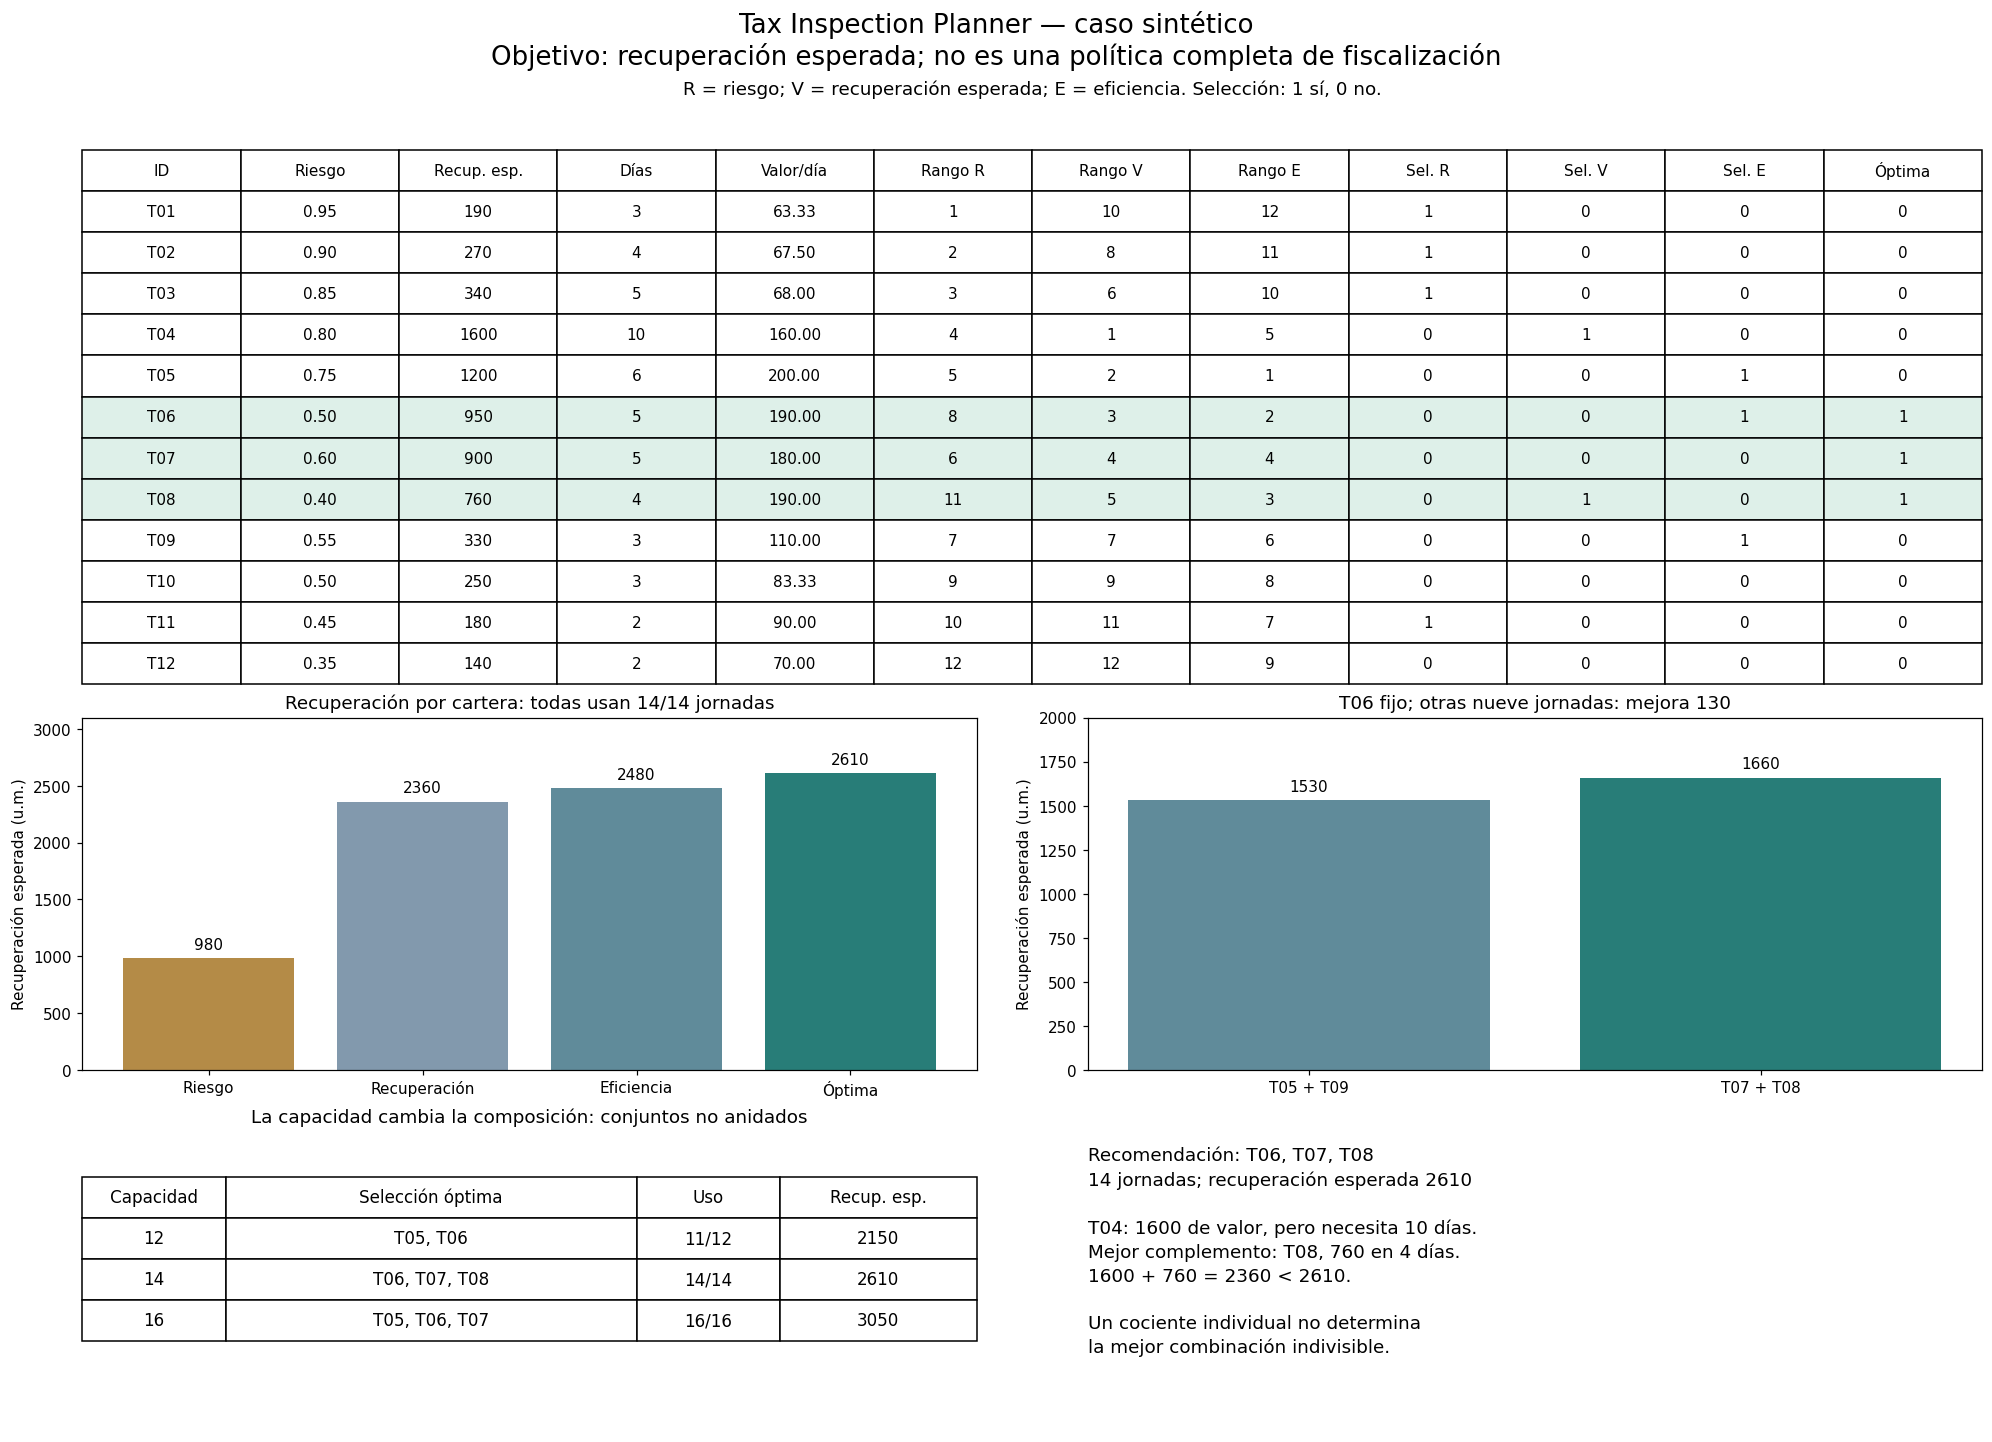

In [31]:
# Caso sintético, objetivo limitado; no constituye una política real de fiscalización.
# La práctica exige considerar legalidad, equidad, debido proceso, disuasión,
# muestreo, incertidumbre y prioridades institucionales. No hay atributos protegidos.

sensitivity_ax.axis("off")
sensitivity_table = sensitivity_ax.table(
    cellText=[
        [
            r.inspection_days_available,
            r.selected_taxpayer_ids.replace(";", ", "),
            f"{r.inspection_days_used}/{r.inspection_days_available}",
            f"{r.total_expected_recovery:.0f}",
        ]
        for r in capacity_sensitivity.itertuples()
    ],
    colLabels=["Capacidad", "Selección óptima", "Uso", "Recup. esp."],
    colWidths=[0.16, 0.46, 0.16, 0.22],
    cellLoc="center",
    bbox=[0, 0.30, 1, 0.55],
)
sensitivity_table.auto_set_font_size(False)
sensitivity_table.set_fontsize(11)
sensitivity_ax.set_title("La capacidad cambia la composición: conjuntos no anidados")
planner.suptitle(
    "Tax Inspection Planner — caso sintético\nObjetivo: recuperación esperada; no es una política completa de fiscalización",
    fontsize=17,
)
display(planner)

In [32]:
# La sensibilidad no sustituye la recomendación base de catorce jornadas.

assert (
    len(inspection_decisions) == 12
    and len(portfolio_comparison) == 4
    and len(capacity_sensitivity) == 3
)
display(
    portfolio_comparison[
        ["policy", "inspection_days_used", "total_expected_recovery", "gap_to_optimum"]
    ],
    capacity_sensitivity[
        [
            "inspection_days_available",
            "selected_taxpayer_ids",
            "total_expected_recovery",
        ]
    ],
)
assert pulp.LpStatus[status] == "Optimal"
assert np.isclose(solver_objective, exhaustive_objective)
assert solver_selection == exhaustive_selection
assert solver_days <= B

,policy,inspection_days_used,total_expected_recovery,gap_to_optimum
0,risk,14,980.0,1630.0
1,expected_recovery,14,2360.0,250.0
2,efficiency,14,2480.0,130.0
3,optimized,14,2610.0,0.0


,inspection_days_available,selected_taxpayer_ids,total_expected_recovery
0,12,T05;T06,2150.0
1,14,T06;T07;T08,2610.0
2,16,T05;T06;T07,3050.0


In [33]:
# Guardamos resultados del escenario base; la figura completa no se vuelve a mostrar.

submission_dir.mkdir(exist_ok=True)
inspection_decisions.to_csv(submission_dir / "inspection_decisions.csv", index=False)
portfolio_comparison.to_csv(submission_dir / "portfolio_comparison.csv", index=False)
capacity_sensitivity.to_csv(submission_dir / "capacity_sensitivity.csv", index=False)
planner.savefig(
    submission_dir / "tax_inspection_planner.png",
    dpi=180,
    bbox_inches="tight",
    facecolor="white",
)
display(
    [
        str(submission_dir / name)
        for name in [
            "inspection_decisions.csv",
            "portfolio_comparison.csv",
            "capacity_sensitivity.csv",
            "tax_inspection_planner.png",
        ]
    ]
)

['../submission/inspection_decisions.csv',
 '../submission/portfolio_comparison.csv',
 '../submission/capacity_sensitivity.csv',
 '../submission/tax_inspection_planner.png']